In [ ]:
import json
import random
import math
import time
import os
import sys
from dataclasses import dataclass, asdict, field    
from enum import Enum
from typing import Optional
from collections import Counter
import requests
from scipy import stats as sp_stats
import re

In [ ]:
# Для генерации синтетического датасета используется модель claude-haiku-4-5-20251001
# тк нельзя использовать семейство DeepSeek и Gemini, а OpenApi очень дорогие токены(
import os
from dotenv import load_dotenv

load_dotenv()

ANTHROPIC_API_KEY = os.getenv("ANTHROPIC_API_KEY")
ANTHROPIC_API_URL = os.getenv("ANTHROPIC_API_URL")
ANTHROPIC_MODEL = os.getenv("ANTHROPIC_MODEL")

DEFAULT_SEED = int(os.getenv("DEFAULT_SEED", 42))
N_EXAMPLES = int(os.getenv("N_EXAMPLES", 200))
OUTPUT_FILE = os.getenv("OUTPUT_FILE", "synthetic_dataset.jsonl")


# Задаем классы с вариантами тестов в синтетических данных


In [9]:
#типы тестов
class TestType(Enum):
    T_TEST = "t"
    ANOVA_TEST = "F"
    CHI2 = "Chi2"
    Z_TEST = "Z"
    CORRELATION = "r"
    Q_TEST = "Q"

In [27]:
# сразу же задаем возможный диапозон числовых значений для каждого вида теста
PARAM_RANGES = {
    TestType.T_TEST: {
        "df_range": (8, 300),
        "stat_range": (0.1, 5.5),
    },
    TestType.ANOVA_TEST: {
        "df1_range": (1, 8),
        "df2_range": (10, 300),
        "stat_range": (0.2, 20.0),
    },
    TestType.CHI2: {
        "df_range": (1, 15),
        "stat_range": (0.1, 40.0),
    },
    TestType.Z_TEST: {
        "n_range": (30, 500),
        "stat_range": (0.1, 4.5),
    },
    TestType.CORRELATION: {
        "n_range": (20, 300),
        "r_range": (-0.95, 0.95),
    },
    TestType.Q_TEST: {
        "df_range": (2, 25),
        "stat_range": (0.5, 50.0),
    },
}


In [10]:
#типы описания тестов
class Environment(Enum):
    APA = "apa"
    NON_APA = "non_apa"
    TEXT = "text"
    TABLE = "table"
    TWO_APA = "two_apa"
    TWO_TEXT = "two_text"
    NO_TEST = "no_test"

In [11]:
#научная область
class SubjectDomain(Enum):
    MEDICINE = "medicine and biology"
    PSYCHOLOGY = "psychology and social sciences"
    ECONOMICS = "economics and finance"


In [12]:
# для данных с ложными интрепритацией задаем типы ошибок  в самом тесте
class ErrorType(Enum):
    NONE = "none"
    WRONG_PVALUE = "wrong_pvalue"
    WRONG_CONCLUSION = "wrong_conclusion"
    TRANSCRIPTION = "transcription"


In [13]:
# для данных с ложными интрепритацией задаем типы ошибок  в интепритации
class ContradictionType(Enum):
    SIG_CALLED_NONSIG = "sig_called_nonsig"           # p < 0.05 but text says "not significant"
    NONSIG_CALLED_SIG = "nonsig_called_sig"           # p > 0.05 but text says "significant"
    EFFECT_DIRECTION = "effect_direction"              # positive effect described as negative or vice versa
    WRONG_ALPHA = "wrong_alpha"                        # uses α=0.10 threshold implicitly while α=0.05 stated
    OVERINTERPRETATION = "overinterpretation"          # marginal p~0.06-0.10 described as "highly significant"
    CI_MISMATCH = "ci_mismatch"                        # CI includes 0 but claims significant effect (or reverse)
    EFFECT_SIZE_MISREAD = "effect_size_misread"        # small effect described as "large" or vice versa
    CAUSAL_FROM_CORRELATION = "causal_from_correlation"  # correlation described with causal language



In [39]:
# задаем класс тестов
@dataclass
class StatTest:
    test_type: str
    statistic: float
    statistic_original: float   # original statistic before any error injection
    df1: int
    df2: Optional[int]
    n_sample: Optional[int]     # sample size (for context in fragments)
    p_value: float              # true p-value (computed from original statistic)
    reported_p: float           # p-value as it appears in the text
    p_equality: str             # "=", "<", ">"
    two_tailed: bool
    consistent: bool
    error_type: str

# Расчет значений

Для некоторых тестов мы можем расчитать стат. характеристики корректно через scipy -- сделаем жто для точности и правдоподобности генерируемых данных

In [16]:
def compute_p_value(test_type, statistic, df1, df2, two_tailed):
    if test_type == TestType.T_TEST:
        p = sp_stats.t.sf(abs(statistic), df1)
        return 2 * p if two_tailed else p

    elif test_type == TestType.F_TEST:
        return sp_stats.f.sf(statistic, df1, df2)

    elif test_type == TestType.CHI2:
        return sp_stats.chi2.sf(statistic, df1)

    elif test_type == TestType.Z_TEST:
        p = sp_stats.norm.sf(abs(statistic))
        return 2 * p if two_tailed else p

    elif test_type == TestType.CORRELATION:
        n = df1
        df = n - 2
        if abs(statistic) >= 1.0:
            return 0.0
        t_val = statistic * math.sqrt(df / (1 - statistic ** 2))
        p = sp_stats.t.sf(abs(t_val), df)
        return 2 * p if two_tailed else p

    elif test_type == TestType.Q_TEST:
        return sp_stats.chi2.sf(statistic, df1)

    return 0.05 # самое частовстречающееся значение

In [21]:
print("t(208) = 2.20:", compute_p_value(TestType.T_TEST, 2.20, 28, None, True))
print("F(2) = 12.3:", compute_p_value(TestType.F_TEST, 12.3, 1, 45, True))
print("r = 0.52, n=50:", compute_p_value(TestType.CORRELATION, 0.52, 50, None, True))

t(208) = 2.20: 0.0362254847788378
F(2) = 12.3: 0.0010394145687042536
r = 0.52, n=50: 0.00010867053949703478


# Генерация теста

Сначала гененрируем численные параметры рандомно


In [22]:
def _generate_effect_size(test_type, statistic, df1, df2):
    if test_type == TestType.T_TEST:
        d = round(abs(statistic) * math.sqrt(2 / max(df1, 1)), 2)
        return min(d, 3.0), "d"
    elif test_type == TestType.F_TEST:
        eta2 = round((statistic * df1) / (statistic * df1 + df2), 3)
        return eta2, "partial_eta2"
    elif test_type == TestType.CHI2:
        n_approx = max(df1 * 20, 30)
        phi = round(math.sqrt(statistic / n_approx), 3)
        return min(phi, 1.0), "phi"
    elif test_type == TestType.CORRELATION:
        return abs(statistic), "r"
    elif test_type == TestType.Z_TEST:
        return min(round(abs(statistic) * 0.5, 2), 3.0), "d"
    return None, None

In [40]:
def generate_stat_test(test_type=None, error_type=None):
    test_type = random.choice(list(TestType))
    error_type = random.choices(list(ErrorType))[0]
    #для двусторонних t-test и z-test задаем отдельно условие
    two_tailed = test_type not in (TestType.T_TEST, TestType.Z_TEST) or random.random() < 0.8
    consistent = (error_type == ErrorType.NONE)
    p = PARAM_RANGES[test_type]
    df2, n_sample = None, None

    # параметры по типу теста
    if test_type == TestType.T_TEST:
        df1 = random.randint(*p["df_range"])
        stat = round(random.uniform(*p["stat_range"]), 2)
        if random.random() < 0.4:
          stat = -stat
        n_sample = df1 + random.choice([1, 2])

    elif test_type == TestType.F_TEST:
        df1 = random.randint(*p["df1_range"])
        df2 = random.randint(*p["df2_range"])
        stat = round(random.uniform(*p["stat_range"]), 2)
        n_sample = df1 + df2 + 1

    elif test_type == TestType.CHI2:
        df1 = random.randint(*p["df_range"])
        stat = round(random.uniform(*p["stat_range"]), 2)
        n_sample = random.randint(30, 500)

    elif test_type == TestType.Z_TEST:
        n_sample = random.randint(*p["n_range"])
        df1 = n_sample
        stat = round(random.uniform(*p["stat_range"]), 2)
        if random.random() < 0.3: stat = -stat

    elif test_type == TestType.CORRELATION:
        n_sample = random.randint(*p["n_range"])
        df1 = n_sample
        stat = round(random.uniform(*p["r_range"]), 2)
        if abs(stat) < 0.05:

            stat = round(random.choice([-1, 1]) * random.uniform(0.1, 0.4), 2)
    elif test_type == TestType.Q_TEST:
        df1 = random.randint(*p["df_range"])
        stat = round(random.uniform(*p["stat_range"]), 2)
        n_sample = random.randint(3, 30)

    true_p = compute_p_value(test_type, stat, df1, df2, two_tailed)
    true_p = max(1e-10, min(0.9999, true_p))
    stat_orig = stat

    # reported p — либо честный, либо с ошибкой
    if consistent:
        reported_p = round(true_p, random.choice([2, 3, 4]))
        if random.random() < 0.5:
            p_eq = "="
        elif true_p < 0.001:  p_eq, reported_p = "<", 0.001
        elif true_p < 0.01:   p_eq, reported_p = "<", 0.01
        elif true_p < 0.05:   p_eq, reported_p = "<", 0.05
        elif random.random() < 0.7: p_eq = "="
        else:                 p_eq, reported_p = ">", 0.05
    elif error_type == ErrorType.WRONG_PVALUE:
        reported_p = round(random.uniform(0.06, 0.60) if true_p < 0.05 else random.uniform(0.001, 0.04), 3)
        p_eq = "="
    elif error_type == ErrorType.ROUNDING:
        if 0.005 < true_p < 0.05:
            reported_p = round(true_p, 1) or 0.1
        else:
            reported_p = round(true_p + random.uniform(0.01, 0.03), 2)
        p_eq = "="
    elif error_type == ErrorType.TRANSCRIPTION:
        stat = round(stat + random.choice([-1, 1]) * random.uniform(0.3, 1.5), 2)
        reported_p = round(true_p, 3)
        p_eq = "="
    else:  # WRONG_CONCLUSION
        reported_p, p_eq = round(true_p, 3), "="

    return StatTest(
        test_type=test_type.value, statistic=round(stat, 2),
        statistic_original=round(stat_orig, 2),
        df1=df1, df2=df2, n_sample=n_sample,
        p_value=round(true_p, 8), reported_p=reported_p,
        p_equality=p_eq, two_tailed=two_tailed,
        consistent=consistent, error_type=error_type.value,
    )

In [42]:
random.seed(42)

# один тест каждого типа — посмотрим что получается
for tt in TestType:
    t = generate_stat_test(test_type=tt, error_type=ErrorType.NONE)
    print(f"{t.test_type:5s}  stat={t.statistic:8.2f}  df1={t.df1}  df2={t.df2}  "
          f"p={t.p_value:.6f}  reported_p {t.p_equality} {t.reported_p}  ")

Q      stat=   14.11  df1=25  df2=None  p=0.959781  reported_p = 0.96  
r      stat=   -0.89  df1=236  df2=None  p=0.000000  reported_p = 0.0  
r      stat=    0.41  df1=121  df2=None  p=0.000003  reported_p = 0.02  
Z      stat=    3.92  df1=444  df2=None  p=0.000089  reported_p = 0.146  
Z      stat=   -1.58  df1=420  df2=None  p=0.114107  reported_p = 0.005  
Chi2   stat=    1.83  df1=13  df2=None  p=0.999863  reported_p = 1.02  


In [45]:
# с ошибкой — wrong_pvalue
t_err = generate_stat_test(test_type=TestType.T_TEST, error_type=ErrorType.TRANSCRIPTION)
print(f"true p = {t_err.p_value:.6f}, reported p = {t_err.reported_p}, consistent = {t_err.consistent}")

true p = 0.008770, reported p = 0.009, consistent = False


In [46]:
# сгенерируем 500штук и посмотрим качество
random.seed(42)

tests = [generate_stat_test() for _ in range(500)]

In [51]:
# распределение по типам
type_counts = Counter(t.test_type for t in tests)
for k, v in sorted(type_counts.items()):
    print(f"  {k:5s}: {v:3d} ")

  Chi2 :  66 
  F    :  78 
  Q    : 100 
  Z    :  83 
  r    :  87 
  t    :  86 


In [52]:
err_counts = Counter(t.error_type for t in tests)
for k, v in sorted(err_counts.items()):
    print(f"  {k:18s}: {v:3d}")

  none              : 107
  rounding          : 100
  transcription     : 103
  wrong_conclusion  : 102
  wrong_pvalue      :  88


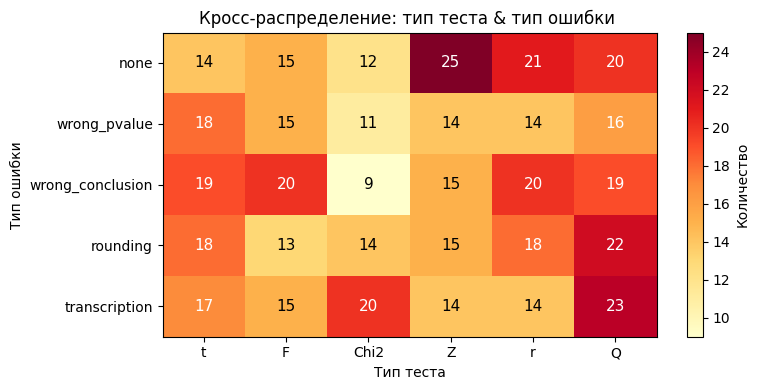

In [57]:
import matplotlib.pyplot as plt
import numpy as np

# собираем кросс-таблицу
test_types_order = ["t", "F", "Chi2", "Z", "r", "Q"]
error_types_order = ["none", "wrong_pvalue", "wrong_conclusion", "rounding", "transcription"]

cross = {}
for et in error_types_order:
    cross[et] = {}
    for tt in test_types_order:
        cross[et][tt] = 0

for t in tests:
    if t.test_type in test_types_order and t.error_type in error_types_order:
        cross[t.error_type][t.test_type] += 1
matrix = np.array([[cross[et][tt] for tt in test_types_order] for et in error_types_order])

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(matrix, cmap="YlOrRd", aspect="auto")

ax.set_xticks(range(len(test_types_order)))
ax.set_xticklabels(test_types_order)
ax.set_yticks(range(len(error_types_order)))
ax.set_yticklabels(error_types_order)
ax.set_xlabel("Тип теста")
ax.set_ylabel("Тип ошибки")
ax.set_title("Кросс-распределение: тип теста & тип ошибки ")
for i in range(len(error_types_order)):
    for j in range(len(test_types_order)):
        val = matrix[i, j]
        color = "white" if val > matrix.max() * 0.6 else "black"
        ax.text(j, i, str(val), ha="center", va="center", color=color, fontsize=11)

plt.colorbar(im, ax=ax, label="Количество")
plt.tight_layout()
plt.show()


## Вывод: генерация работает корректно


# Генерация текста статьи под полученные численные характеристики теста


In [53]:
STYLE_INSTRUCTIONS = {
    Environment.APA: (
        "Report each statistical test result EXACTLY in strict APA 7th edition format. "
        "Example: t(28) = 2.20, p = .03."
    ),
    Environment.NON_APA: (
        "Report each statistical test result in a NON-APA style, "
        "like: df = 28, t = 2.20, p = 0.03. Do NOT use APA parenthetical notation."
    ),
    Environment.TEXT: (
        "Embed each statistical result naturally within prose. "
        "The numbers must appear within flowing text, not as standalone formulas."
    ),
    Environment.TABLE: (
        "Present results in a markdown table: Variable | Test | Statistic | df | p-value. "
        "Add 2-3 sentences before and after."
    ),
    Environment.TWO_APA: (
        "Report two tests in a SINGLE APA-style sentence."
    ),
    Environment.TWO_TEXT: (
        "Embed two tests in a SINGLE flowing prose sentence."
    ),
}


def format_test_for_prompt(test, env):
    t, s, df1, df2, p, sign = (
        test.test_type, test.statistic, test.df1, test.df2, test.reported_p, test.p_equality,
    )
    tail_note = "" if test.two_tailed else " (one-tailed)"

    if t == "F":     base = f"F({df1}, {df2}) = {s}, p {sign} {p}"
    elif t == "t":   base = f"t({df1}) = {s}, p {sign} {p}{tail_note}"
    elif t == "Chi2": base = f"χ²({df1}) = {s}, p {sign} {p}"
    elif t == "Z":   base = f"Z = {s}, p {sign} {p}{tail_note}"
    elif t == "r":
        n = test.n_sample or df1
        base = f"r({n - 2}) = {s}, p {sign} {p}"
    else:
        base = f"Q({df1}) = {s}, p {sign} {p}"

    return base

In [59]:
def build_prompt(tests, domain, env, error_type):
    """Build the LLM prompt for generating an article fragment."""
    domain_str = domain.value

    if env == Environment.NO_TEST:
        return (
            f"You are an expert academic writer in {domain_str}. "
            f"Write a realistic 200-300 word excerpt from a scientific article's "
            f"Methods or Discussion section. "
            f"CRITICAL: The excerpt must NOT contain ANY statistical test results, "
            f"p-values, test statistics, degrees of freedom, or effect sizes. "
            f"Write about methodology, theoretical background, or implications only. "
            f"Output ONLY the excerpt text, nothing else."
        )

    test_strings = [format_test_for_prompt(t, env) for t in tests]
    tests_block = "\n".join(f"  {i+1}. {s}" for i, s in enumerate(test_strings))

    style = STYLE_INSTRUCTIONS.get(env, STYLE_INSTRUCTIONS[Environment.APA])

    if error_type == ErrorType.WRONG_CONCLUSION:
        conclusion = (
            "\nCRITICAL REQUIREMENT: After reporting each test, write a textual conclusion "
            "that DELIBERATELY CONTRADICTS the p-value — e.g., state 'the effect was "
            "statistically significant' when p > 0.05, or 'no significant difference was "
            "found' when p < 0.05. This contradiction must be subtle and realistic."
        )
    else:
        conclusion = (
            "\nAfter reporting each test, include a brief CORRECT textual interpretation "
            "(e.g., 'the result was statistically significant' if p < 0.05, or "
            "'the difference was not statistically significant' if p > 0.05)."
        )

    prompt = (
        f"You are an expert academic writer in {domain_str}. "
        f"Write a realistic 200-350 word excerpt from a scientific article's Results section.\n\n"
        f"The excerpt MUST contain EXACTLY these {len(tests)} statistical test result(s), "
        f"using the EXACT numerical values provided:\n"
        f"{tests_block}\n\n"
        f"STRICT RULES:\n"
        f"1. Use the EXACT test statistic values, degrees of freedom, and p-values given above. "
        f"Do NOT round, modify, or recalculate any numbers.\n"
        f"2. {style}\n"
        f"3. {conclusion}\n"
        f"4. Add realistic context (sample descriptions, variable names, study design) "
        f"appropriate for {domain_str}.\n"
        f"5. Do NOT include any statistical tests beyond those listed above.\n"
        f"6. Output ONLY the excerpt text. No preamble, no commentary.\n"
    )
    return prompt


In [63]:
random.seed(42)
demo_tests = [generate_stat_test(TestType.F_TEST, ErrorType.NONE)]
demo_prompt = build_prompt(demo_tests, SubjectDomain.PSYCHOLOGY, Environment.APA, ErrorType.NONE)
print(demo_prompt)

You are an expert academic writer in psychology and social sciences. Write a realistic 200-350 word excerpt from a scientific article's Results section.

The excerpt MUST contain EXACTLY these 1 statistical test result(s), using the EXACT numerical values provided:
  1. Q(25) = 14.11, p = 0.96

STRICT RULES:
1. Use the EXACT test statistic values, degrees of freedom, and p-values given above. Do NOT round, modify, or recalculate any numbers.
2. Report each statistical test result EXACTLY in strict APA 7th edition format. Example: t(28) = 2.20, p = .03.
3. 
After reporting each test, include a brief CORRECT textual interpretation (e.g., 'the result was statistically significant' if p < 0.05, or 'the difference was not statistically significant' if p > 0.05).
4. Add realistic context (sample descriptions, variable names, study design) appropriate for psychology and social sciences.
5. Do NOT include any statistical tests beyond those listed above.
6. Output ONLY the excerpt text. No prea

In [76]:
# идем к модели по апи ключу
def call_anthropic(prompt, api_key):
    headers = {"Content-Type": "application/json", "x-api-key": api_key, "anthropic-version": "2023-06-01"}
    payload = {"model": ANTHROPIC_MODEL, "max_tokens": 1000, "temperature": 0.7,
               "messages": [{"role": "user", "content": prompt}]}
    for attempt in range(3):
        try:
            resp = requests.post(ANTHROPIC_API_URL, headers=headers, json=payload, timeout=90)
            resp.raise_for_status()
            return resp.json()["content"][0]["text"].strip()
        except Exception as e:
            print(f"  [retry {attempt+1}] {e}")
            time.sleep(2 ** attempt)
    return ""


def call_llm(prompt, api_key, provider="deepseek"):
    if provider == "anthropic":
        return call_anthropic(prompt, api_key)
    return call_deepseek(prompt, api_key)




def validate_fragment(fragment, tests, env):
    """Проверяем что LLM вставила нужные числа в текст."""
    if env == Environment.NO_TEST:
        has_p = bool(re.search(r'p\s*[=<>]\s*0?\.\d+', fragment, re.I))
        has_stat = bool(re.search(r'[FtZrQ]\s*[\(=]\s*\d', fragment))
        return {"valid": not has_p and not has_stat,
                "issues": ["contains_stats"] if (has_p or has_stat) else []}

    issues = []
    for i, test in enumerate(tests):
        stat_str = str(abs(test.statistic))
        if stat_str not in fragment and f"-{stat_str}" not in fragment:
            if f"{abs(test.statistic):.1f}" not in fragment:
                issues.append(f"test_{i}_stat_missing ({stat_str})")
        p_str = str(test.reported_p)
        if p_str not in fragment and f"{test.reported_p:.2f}" not in fragment:
            issues.append(f"test_{i}_p_missing ({p_str})")

    return {"valid": len(issues) == 0, "issues": issues}


# Полная генерация датасета


In [ ]:
random.seed(42)
N = 500
OUTPUR_STAT = "tests_debug.jsonl"
OUTPUT = "synthetic_dataset.jsonl"
PROVIDER = "anthropic"
SEED = 42
RESUME = True
api_key = ANTHROPIC_API_KEY
with open(OUTPUR_STAT, "w") as f:
    for i in range(N):
        t = generate_stat_test()
        record = {"id": i, **asdict(t)}
        f.write(json.dumps(record, ensure_ascii=False) + "\n")



In [83]:
random.seed(777)

# генерим флоу
test = generate_stat_test(test_type=TestType.F_TEST, error_type=ErrorType.WRONG_CONCLUSION)
env = Environment.TEXT
domain = SubjectDomain.PSYCHOLOGY

print(f"  Тип:          {test.test_type}")
print(f"  Статистика:   {test.statistic}")
print(f"  df1, df2:     {test.df1}, {test.df2}")
print(f"  True p:       {test.p_value:.6f}")
print(f"  Reported p:   {test.p_equality} {test.reported_p}")
print(f"  Consistent:   {test.consistent}")
print(f"  Error type:   {test.error_type}")
print(f"  Significant:  {'да' if test.p_value < 0.05 else 'нет'}")
print(f"  Environment:  {env.value}")
print(f"  Domain:       {domain.value}")

#prompt
prompt = build_prompt([test], domain, env, ErrorType.WRONG_CONCLUSION)
print(prompt)

#llm result
api_key = ANTHROPIC_API_KEY
provider = "deepseek" if os.getenv("DEEPSEEK_API_KEY") else "anthropic"

fragment = call_llm(prompt, api_key, provider)
print(fragment)

  Тип:          F
  Статистика:   16.66
  df1, df2:     6, 148
  True p:       0.000000
  Reported p:   = 0.0
  Consistent:   False
  Error type:   wrong_conclusion
  Significant:  да
  Environment:  text
  Domain:       psychology and social sciences
You are an expert academic writer in psychology and social sciences. Write a realistic 200-350 word excerpt from a scientific article's Results section.

The excerpt MUST contain EXACTLY these 1 statistical test result(s), using the EXACT numerical values provided:
  1. F(6, 148) = 16.66, p = 0.0

STRICT RULES:
1. Use the EXACT test statistic values, degrees of freedom, and p-values given above. Do NOT round, modify, or recalculate any numbers.
2. Embed each statistical result naturally within prose. The numbers must appear within flowing text, not as standalone formulas.
3. 
CRITICAL REQUIREMENT: After reporting each test, write a textual conclusion that DELIBERATELY CONTRADICTS the p-value — e.g., state 'the effect was statistically sig

## Генерация всего синтетического датасета(500 примеров)


In [85]:
# основной цикл генерации

random.seed(SEED)

# составляем план генерации - задаем долю сгенерированных примеров для каждого типа описания теста
env_ratios = {
        Environment.APA: 0.20, Environment.NON_APA: 0.12,
        Environment.TEXT: 0.20, Environment.TABLE: 0.10,
        Environment.TWO_APA: 0.10, Environment.TWO_TEXT: 0.08,
        Environment.NO_TEST: 0.20,
    }
plan = []
domains = list(SubjectDomain)
test_types = list(TestType)

for env, ratio in env_ratios.items():
  for _ in range(max(1, round(N * ratio))):
    domain = random.choice(domains)
    if env == Environment.NO_TEST:
        plan.append((env, domain, ErrorType.NONE, []))
    else:
        n_tests = 2 if env in (Environment.TWO_APA, Environment.TWO_TEXT) else \
                        random.choices([1, 2, 3], weights=[50, 35, 15])[0]
        error = random.choices(list(ErrorType), weights=[55, 15, 10, 12, 8])[0]
        chosen = [random.choice(test_types) for _ in range(n_tests)]
        plan.append((env, domain, error, chosen))

random.shuffle(plan)

skip_n = 0
if RESUME and os.path.exists(OUTPUT):
    with open(OUTPUT) as f:
        skip_n = sum(1 for _ in f)
    print(f"Resume: {skip_n} уже есть, продолжаем с #{skip_n+1}")

written, skipped = skip_n, 0
valid_pass, valid_fail = 0, 0

mode = "a" if RESUME else "w"
with open(OUTPUT, mode, encoding="utf-8") as f:
    for i, (env, domain, error_type, test_types_list) in enumerate(plan):
        if i < skip_n:
            continue

        # генерим тесты
        if env == Environment.NO_TEST:
            gen_tests = []
            consistent = True
        else:
            gen_tests = [generate_stat_test(tt, error_type) for tt in test_types_list]
            consistent = all(t.consistent for t in gen_tests)

        prompt = build_prompt(gen_tests, domain, env, error_type)

        print(f"[{i+1}/{len(plan)}] env={env.value:8s} tests={len(gen_tests)} err={error_type.value}", end=" ... ", flush=True)

        fragment = call_llm(prompt, api_key, PROVIDER)

        if not fragment:
            print("SKIP (empty)")
            skipped += 1
            continue

        val = validate_fragment(fragment, gen_tests, env)
        if val["valid"]: valid_pass += 1
        else: valid_fail += 1

        record = {
            "example_id": written,
            "environment": env.value,
            "domain": domain.value,
            "n_tests": len(gen_tests),
            "tests": [asdict(t) for t in gen_tests],
            "fragment": fragment,
            "prompt_used": prompt,
            "label_consistent": consistent,
            "error_type": error_type.value,
            "validation": val,
        }
        f.write(json.dumps(record, ensure_ascii=False) + "\n")
        f.flush()
        written += 1

        status = "✓" if val["valid"] else f"⚠ {val['issues']}"
        print(f"OK ({len(fragment)} chars) {status}")
        time.sleep(0.3)

print(f"\n{'='*50}")
print(f"Готово! Written: {written}, Skipped: {skipped}")
print(f"Validation: {valid_pass} pass, {valid_fail} fail")
print(f"Output: {OUTPUT}")

Resume: 100 уже есть, продолжаем с #101
[101/500] env=no_test  tests=0 err=none ... OK (1894 chars) ✓
[102/500] env=two_apa  tests=2 err=none ... OK (1782 chars) ✓
[103/500] env=table    tests=3 err=none ... OK (2352 chars) ✓
[104/500] env=text     tests=3 err=wrong_pvalue ... OK (1884 chars) ✓
[105/500] env=two_apa  tests=2 err=none ... OK (1793 chars) ✓
[106/500] env=apa      tests=2 err=none ... OK (1907 chars) ⚠ ['test_0_p_missing (0.0)', 'test_1_p_missing (0.01)']
[107/500] env=no_test  tests=0 err=none ... OK (2103 chars) ✓
[108/500] env=two_apa  tests=2 err=wrong_pvalue ... OK (1940 chars) ✓
[109/500] env=apa      tests=1 err=none ... OK (1938 chars) ⚠ ['test_0_p_missing (0.734)']
[110/500] env=no_test  tests=0 err=none ... OK (1678 chars) ✓
[111/500] env=apa      tests=2 err=wrong_conclusion ... OK (2058 chars) ✓
[112/500] env=two_apa  tests=2 err=transcription ... OK (2109 chars) ✓
[113/500] env=two_text tests=2 err=wrong_pvalue ... OK (1937 chars) ✓
[114/500] env=table    tes